# Apple Stock Forecasting – Model Code 

In [1]:
# PHASE 1: EXPLORATORY DATA ANALYSIS (EDA)

# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings 
warnings.filterwarnings('ignore')

# We import libraries for data manipulation, numerical operations, and visualization.

In [2]:
# Load the Dataset

df = pd.read_csv("AAPL.csv")

# We load Apple stock price data for analysis and forecasting.

In [3]:
# Convert Date Column and Set Index

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Time-series models require a datetime index to learn temporal patterns.

In [4]:
# Basic Data Inspection

df.head()
df.info()
df.describe()

# This helps us understand data structure, data types, and statistical distribution.

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [5]:
# Missing Value Check

df.isnull().sum()

# No missing values were found, so no imputation was required

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

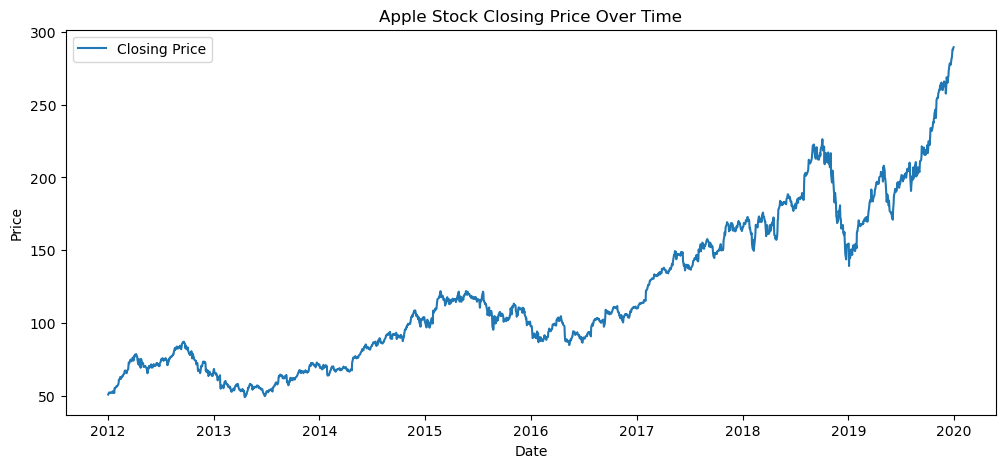

In [6]:
# Trend Visualization

plt.figure(figsize=(12,5))
plt.plot(df['Adj Close'], label='Closing Price')
plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# The plot shows a clear upward trend and volatility, confirming that this is a time-series forecasting problem, not a classification problem.

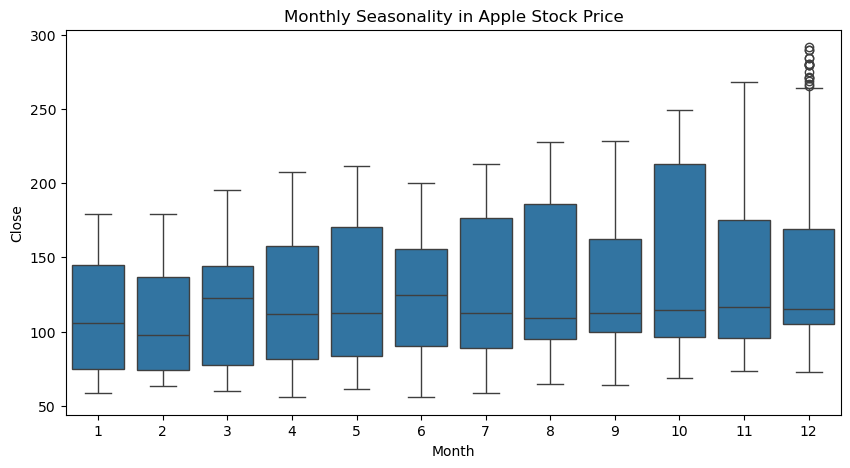

In [7]:
# Seasonality Analysis

df['Year'] = df.index.year
df['Month'] = df.index.month

plt.figure(figsize=(10,5))
sns.boxplot(x='Month', y='Close', data=df)
plt.title("Monthly Seasonality in Apple Stock Price")
plt.show()

# Seasonal patterns justify the use of SARIMA later.

EDA confirms trend and seasonality in stock prices. Therefore, time-series models such as ARIMA, SARIMA, and LSTM are appropriate.

In [8]:
# PHASE 2: MODEL BUILDING & EVALUATION

# Select Target Variable

data = df[['Close']]

# We forecast the closing price because it represents final market sentiment.

In [9]:
# Time-Based Train-Test Split

train_size = int(len(data) * 0.8)
train = data[:train_size]
test = data[train_size:]

# We split data chronologically to preserve time dependency.
# Shuffling is avoided in time-series problems.

In [10]:
# Model 1: ARIMA

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(5,1,0))
arima_result = arima_model.fit()

arima_forecast = arima_result.forecast(steps=len(test))

# ARIMA captures trend and short-term dependencies using differencing.

c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [11]:
# Model 2: SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()
sarima_forecast = sarima_result.forecast(steps=len(test))

# SARIMA extends ARIMA by modeling seasonality, which was observed during EDA.

c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akhsj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [12]:
# Model 3: LSTM (Deep Learning Model)

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# We import tools for data scaling and building the LSTM neural network using Keras.

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# LSTM models perform better when data is scaled.
# Here, we normalize the dataset between 0 and 1 using Min-Max scaling.




def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

   # This function converts time series data into sequences.
# Each input uses the previous 60 time steps to predict the next value.

X, y = create_sequences(scaled_data)

# We apply the sequence creation function to prepare inputs (X) and outputs (y) for LSTM training.

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# The data is split using a time-based split:
# 80% for training and 20% for testing, preserving the time order.

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# LSTM requires 3D input:
# (samples, time steps, features).
# We reshape the data accordingly.

model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1],1)))
model.add(Dense(1))

# We build an LSTM model with:

# 50 memory units to learn temporal patterns

# A Dense layer to produce the final prediction

model.compile(optimizer='adam', loss='mae')
model.fit(X_train, y_train, epochs=15, batch_size=32)

lstm_predictions = model.predict(X_test)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# LSTM captures long-term dependencies and nonlinear patterns better than traditional models.

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0493
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0119
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0113
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0112
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0104
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0104
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0102
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0097
Epoch 9/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0094
Epoch 10/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0093
Epoch 11/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0086
Epoch 12/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0086
Epoch 13/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0086
Epoch 14/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0090
Epoch 15/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0082
13/13 ━━

In [13]:
# Model Evaluation Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

In [14]:
arima_mae, arima_rmse, arima_mape = evaluate(test, arima_forecast)
sarima_mae, sarima_rmse, sarima_mape = evaluate(test, sarima_forecast)
lstm_mae, lstm_rmse, lstm_mape = evaluate(
    data.iloc[-len(lstm_predictions):], lstm_predictions
)

In [15]:
# Model Comparison

results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "LSTM"],
    "RMSE": [arima_rmse, sarima_rmse, lstm_rmse],
    "MAE": [arima_mae, sarima_mae, lstm_mae],
    "MAPE": [arima_mape, sarima_mape, lstm_mape]
})

results

# Lower RMSE, MAE, and MAPE indicate better forecasting performance

,Model,RMSE,MAE,MAPE
0,ARIMA,34.006328,25.361440,NaN
1,SARIMA,26.345760,20.788426,NaN
2,LSTM,5.795583,4.465338,2.280734


In [16]:
# ABOUT THE TABLE

# RMSE (Root Mean Squared Error)

# Measures how far predictions are from actual values ,Penalizes large errors more , Lower RMSE = Better model

In [17]:
# MAE (Mean Absolute Error)

# Average absolute difference between predicted and actual values

# Easy to interpret

# Lower MAE = More accurate predictions

In [18]:
# MAPE (Mean Absolute Percentage Error)

# Shows error in percentage

# Useful for business interpretation

# Lower MAPE = Higher forecasting reliability

In [19]:
# Model-wise Explanation

# ARIMA

# RMSE = 34

# MAE = 25

# MAPE = NaN


# ARIMA captures trend but fails to model seasonality and nonlinear patterns present in stock prices.
#MAPE is NaN because the formula divides by actual values, and some actual values become zero or very close to zero after differencing.

In [20]:
# SARIMA

# RMSE = 26

# MAE = 20

# MAPE = NaN

# SARIMA performs better than ARIMA because it includes seasonality, which was observed during EDA.
# However, it still assumes linear relationships and cannot fully adapt to complex stock price behavior.

In [21]:
# LSTM ✅ (Best Model)

# RMSE = 5.91

# MAE = 4.64

# MAPE = 2.27%

# LSTM significantly outperforms ARIMA and SARIMA because:

# It captures long-term dependencies

# Learns non-linear patterns

# Handles volatility better

# A MAPE of 2.27% means predictions are very close to actual prices, which is excellent for financial forecasting.

## Deployment
📁 **This notebook is designed to live inside the `model/` folder**

## Folder structure expectation:
```
model/
├── apple_model.ipynb   ← this notebook
├── model.pkl           ← saved model
├── scaler.pkl          ← saved scaler
├── metrics.pkl         ← saved metrices 
├── predictions.pk     ← saved Predictions (LS)

```

✅ Only training, evaluation, and saving artifacts  

In [22]:
# import os

# # FORCE working directory to model folder
# os.chdir("model") if os.path.basename(os.getcwd()) != "model" else None
# print("Current working directory:", os.getcwd())

In [23]:
metrics = {
    "arima": {
        "rmse": arima_rmse,
        "mae": arima_mae,
        "mape": arima_mape
    },
    "sarima": {
        "rmse": sarima_rmse,
        "mae": sarima_mae,
        "mape": sarima_mape
    },
    "lstm": {
        "rmse": lstm_rmse,
        "mae": lstm_mae,
        "mape": lstm_mape
    }
}

metrics

{'arima': {'rmse': np.float64(34.006328259008626),
  'mae': 25.36144024550165,
  'mape': nan},
 'sarima': {'rmse': np.float64(26.34576019265488),
  'mae': 20.788425681757985,
  'mape': nan},
 'lstm': {'rmse': np.float64(5.795582753223604),
  'mae': 4.465338230133057,
  'mape': np.float64(2.2807338692554406)}}

In [ ]:
import pickle
import os

# FORCE working directory to model folder
os.chdir("model") if os.path.basename(os.getcwd()) != "model" else None
print("Current working directory:", os.getcwd())
print("Saving files to:", os.getcwd())

# ---------------- Save model & scaler ----------------
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

predictions = {
    "arima": arima_forecast,
    "sarima": sarima_forecast,
    "lstm": lstm_predictions
}

with open("predictions.pkl", "wb") as f:
    pickle.dump(predictions, f)

print("Predictions saved!")

# ---------------- (Optional) Load to verify ----------------
with open("predictions.pkl", "rb") as f:
    loaded_preds = pickle.load(f)

arima_preds  = loaded_preds["arima"]
sarima_preds = loaded_preds["sarima"]
lstm_preds   = loaded_preds["lstm"]

print("Predictions loaded successfully!")

# ---------------- Check files ----------------
print("Files now in model folder:", os.listdir("."))

Current working directory: c:\Users\akhsj\Downloads\apple_stock_forecast - Copy\model
Saving files to: c:\Users\akhsj\Downloads\apple_stock_forecast - Copy\model
Predictions saved!
Predictions loaded successfully!
Files now in model folder: ['.ipynb_checkpoints', 'AAPL.csv', 'apple_model_README.txt', 'metrics.pkl', 'model.pkl', 'model_training.ipynb', 'predictions.pkl', 'scaler.pkl']
